In [1]:
# LOAD DATA

# This notebook assumes you already created a cleaned modeling table in the cleaning notebook:
#   ./outputs/final_model_table_summer.csv

# That table should include:
# - Identifiers: Year, Country, Sport, NOC
# - Features: Prev_Sport_Medals, Athlete_Count, Is_Host, log_Pop, log_GDPpc
# - Targets: Gold, Silver, Bronze (and Total_Medals)

# Why this separation?
# - Cleaning notebook = reproducible ETL
# - Modeling notebook = training, evaluation, prediction, visuals

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_error, r2_score

DATA_PATH = Path("/kaggle/input/datasets/reenamaritapinto/final-model/final_model_table_summer.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (6398, 15)


,Year,Sport,Country,NOC,Prev_Sport_Medals,Athlete_Count,Is_Host,Population,GDP_per_capita,log_Pop,log_GDPpc,Gold,Silver,Bronze,Total_Medals
0,2008,Taekwondo,Afghanistan,AFG,0.0,2,0,27294031.0,2191.5044,17.122179,7.692800,0,0,1,1
1,2012,Taekwondo,Afghanistan,AFG,1.0,2,0,30696958.0,2985.3190,17.239674,8.001797,0,0,1,1
2,2024,Wrestling,Albania,ALB,0.0,0,0,2947436.0,20591.4860,14.896447,9.932682,0,0,2,2
3,1984,Boxing,Algeria,ALG,0.0,7,0,21893853.0,NaN,16.901717,NaN,0,0,2,2
4,1992,Athletics,Algeria,ALG,0.0,9,0,27181094.0,NaN,17.118032,NaN,1,0,0,1


In [3]:
# 1) FEATURES & TARGETS

# We predict medal counts (Gold/Silver/Bronze) which are non-negative integers.
# We use a Poisson objective later because it is designed for count outcomes.

In [4]:
FEATURES = [
    "Prev_Sport_Medals",
    "Athlete_Count",
    "Is_Host",
    "log_Pop",
    "log_GDPpc"
]

TARGETS = ["Gold", "Silver", "Bronze"]

df = df.sort_values("Year")

In [5]:
# 2) Time-aware split (train on past, validate on latest year)

# We validate on the most recent Olympics year available in your dataset.
# This avoids leakage: the model only learns from past Olympics to predict a future Olympics

In [6]:
VAL_YEAR = df["Year"].max()
print("Validation Year:", VAL_YEAR)

train_df = df[df["Year"] < VAL_YEAR].copy()
val_df   = df[df["Year"] == VAL_YEAR].copy()

X_train = train_df[FEATURES]
X_val   = val_df[FEATURES]

Validation Year: 2024


In [7]:
# Insight:
# A random split would mix years and leak future info.
# Time-based validation is much closer to real forecasting.

In [8]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
# 3) MODEL TRAINING (XGBoost Poisson)

# We train three separate models: Gold, Silver, Bronze.
# Poisson objective is a natural choice for count data (medals).

In [10]:
models = {}

for target in TARGETS:
    model = XGBRegressor(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="count:poisson",
        random_state=42
    )
    
    model.fit(X_train, train_df[target])
    models[target] = model
    
    preds = model.predict(X_val)
    mae = mean_absolute_error(val_df[target], preds)
    print(f"{target} MAE:", round(mae, 4))

Gold MAE: 0.676
Silver MAE: 0.6176
Bronze MAE: 0.7104


In [11]:
# Insight:
# Separate medal-type models allow different dynamics (gold may be harder to predict than bronze).
# Another option is to predict Total_Medals only, but medal-type gives richer output for storytelling.

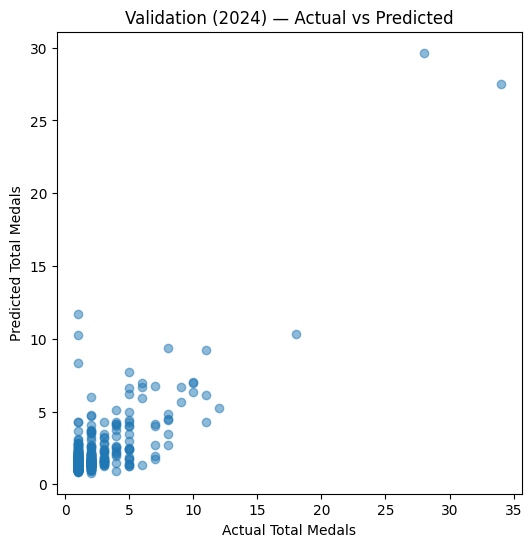

In [12]:
val_results = val_df[["Country","Sport"] + TARGETS].copy()

for target in TARGETS:
    val_results[f"Pred_{target}"] = np.clip(
        models[target].predict(X_val), 0, None
    )

val_results["Actual_Total"] = (
    val_results["Gold"] +
    val_results["Silver"] +
    val_results["Bronze"]
)

val_results["Pred_Total"] = (
    val_results["Pred_Gold"] +
    val_results["Pred_Silver"] +
    val_results["Pred_Bronze"]
)

plt.figure(figsize=(6,6))
plt.scatter(val_results["Actual_Total"], val_results["Pred_Total"], alpha=0.5)
plt.xlabel("Actual Total Medals")
plt.ylabel("Predicted Total Medals")
plt.title(f"Validation ({VAL_YEAR}) — Actual vs Predicted")
plt.show()

In [13]:
# Insight:
# Using log features is important because Population and GDP per capita are extremely skewed.
# Without logs, a few very large or wealthy countries can dominate the learning signal.

In [14]:
# 4) VALIDATION (SPORT × COUNTRY LEVEL)
# This validates how well the model predicts medal outcomes at the Sport × Country granularity.

Validation (Sport×Country) — Total Medals
MAE: 0.927
R2 : 0.674
Corr: 0.821


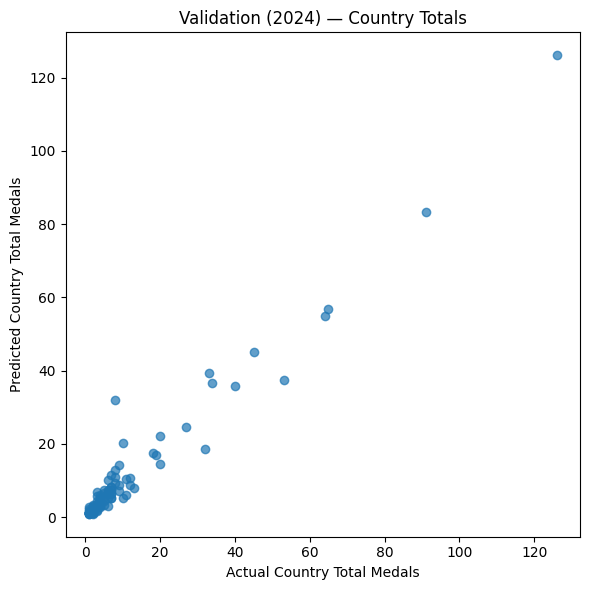

,Country,Actual_Total,Pred_Total
87,United States,126,126.102333
15,China,91,83.366776
33,Great Britain,65,56.873970
30,France,64,55.015999
4,Australia,53,37.391506
47,Japan,45,45.044868
44,Italy,40,35.947643
59,Netherlands,34,36.656570
32,Germany,33,39.364620
77,South Korea,32,18.503185


In [15]:
# sport-country level metrics
mae = mean_absolute_error(val_results["Actual_Total"], val_results["Pred_Total"])
r2  = r2_score(val_results["Actual_Total"], val_results["Pred_Total"])
corr = np.corrcoef(val_results["Actual_Total"], val_results["Pred_Total"])[0,1]

print("Validation (Sport×Country) — Total Medals")
print("MAE:", round(mae, 3))
print("R2 :", round(r2, 3))
print("Corr:", round(corr, 3))

# Country-level validation (much easier to interpret)
country_val = (
    val_results.groupby("Country")[["Actual_Total","Pred_Total"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(6,6))
plt.scatter(country_val["Actual_Total"], country_val["Pred_Total"], alpha=0.7)
plt.xlabel("Actual Country Total Medals")
plt.ylabel("Predicted Country Total Medals")
plt.title(f"Validation ({VAL_YEAR}) — Country Totals")
plt.tight_layout()
plt.show()

country_val.sort_values("Actual_Total", ascending=False).head(15)

In [16]:
# Insight:
# R2 and correlation give you a quick “are we learning signal?” check.
# MAE tells you how far off the model is on average.

In [17]:
# 5) VALIDATION (COUNTRY TOTALS)
# Aggregating to country totals is the most intuitive validation view.

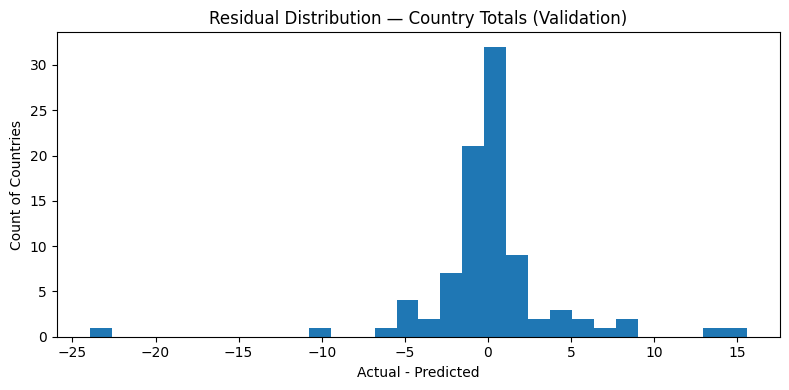

Most under-predicted:


,Country,Actual_Total,Pred_Total,Residual
4,Australia,53,37.391506,15.608494
77,South Korea,32,18.503185,13.496815
30,France,64,55.015999,8.984001
33,Great Britain,65,56.873970,8.126030
15,China,91,83.366776,7.633224
60,New Zealand,20,14.565203,5.434797
88,Uzbekistan,13,7.891118,5.108882
50,Kenya,11,6.124647,4.875353
8,Belgium,10,5.187166,4.812834
44,Italy,40,35.947643,4.052357


Most over-predicted:


,Country,Actual_Total,Pred_Total,Residual
84,Turkey,8,31.957756,-23.957756
66,Poland,10,20.293867,-10.293867
32,Germany,33,39.364620,-6.364620
23,Denmark,9,14.191714,-5.191714
80,Switzerland,8,12.796448,-4.796448
18,Croatia,7,11.534199,-4.534199
76,South Africa,6,10.263294,-4.263294
40,Indonesia,3,6.927799,-3.927799
34,Greece,8,11.054540,-3.054540
27,Egypt,3,5.809960,-2.809960


In [18]:
country_val["Residual"] = country_val["Actual_Total"] - country_val["Pred_Total"]

plt.figure(figsize=(8,4))
plt.hist(country_val["Residual"], bins=30)
plt.title("Residual Distribution — Country Totals (Validation)")
plt.xlabel("Actual - Predicted")
plt.ylabel("Count of Countries")
plt.tight_layout()
plt.show()

# biggest under/over predictions
print("Most under-predicted:")
display(country_val.sort_values("Residual", ascending=False).head(10))

print("Most over-predicted:")
display(country_val.sort_values("Residual", ascending=True).head(10))

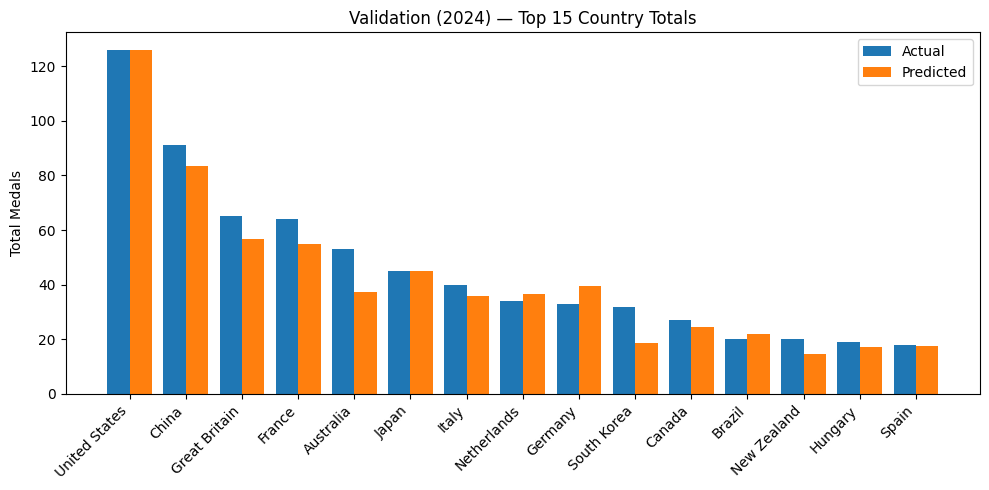

In [19]:
cv = country_val.sort_values("Actual_Total", ascending=False).head(15)

plt.figure(figsize=(10,5))
x = np.arange(len(cv))
plt.bar(x - 0.2, cv["Actual_Total"], width=0.4, label="Actual")
plt.bar(x + 0.2, cv["Pred_Total"], width=0.4, label="Predicted")
plt.xticks(x, cv["Country"], rotation=45, ha="right")
plt.title(f"Validation ({VAL_YEAR}) — Top 15 Country Totals")
plt.ylabel("Total Medals")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# 6) RETRAIN USING ALL HISTORY (PRE-2028)
# After validating, we retrain on all available years before 2028 to maximize training signal.

In [21]:
#Retrain on Full History (Before 2028)
TARGET_YEAR = 2028

train_all = df[df["Year"] < TARGET_YEAR].copy()
X_all = train_all[FEATURES]

models_all = {}

for target in TARGETS:
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="count:poisson",
        random_state=42
    )
    
    model.fit(X_all, train_all[target])
    models_all[target] = model

In [22]:
# Insight:
# This is a standard workflow:
# - validate using last year
# - retrain using full history
# - predict future

In [23]:
# 7) BUILD 2028 FEATURE TABLE

# We need a 2028 row for each (Country × Sport × NOC).
# A simple approach:
# - Use latest observed macro and participation values (e.g., 2024)
# - Set Prev_Sport_Medals = medals from latest Olympics (momentum feature)
# - Add host flag for USA in 2028

In [24]:
latest_year = df["Year"].max()

# Use last observed values per NOC + Sport
last_obs = (
    df[df["Year"] == latest_year]
    [["NOC","Sport","Country","Population","GDP_per_capita","log_Pop","log_GDPpc","Athlete_Count"]]
    .copy()
)

# Previous medals for 2028 = medals from 2024
prev_medals = (
    df[df["Year"] == latest_year]
    [["NOC","Sport","Total_Medals"]]
    .rename(columns={"Total_Medals":"Prev_Sport_Medals"})
)

pred_2028 = last_obs.merge(prev_medals, on=["NOC","Sport"], how="left")

pred_2028["Year"] = TARGET_YEAR
pred_2028["Is_Host"] = (pred_2028["Country"] == "United States").astype(int)

X_2028 = pred_2028[FEATURES]

In [25]:
# Insight:
# This does not “forecast” GDP/population; it treats them as stable proxies of national capacity.
# For a portfolio project, carrying latest macro values forward is acceptable and common.

In [26]:
# Insight:
# This does not “forecast” GDP/population; it treats them as stable proxies of national capacity.
# For a portfolio project, carrying latest macro values forward is acceptable and common.

In [27]:
for target in TARGETS:
    pred_2028[f"Pred_{target}"] = np.clip(
        models_all[target].predict(X_2028),
        0,
        None
    )

pred_2028["Pred_Gold"] = np.rint(pred_2028["Pred_Gold"])
pred_2028["Pred_Silver"] = np.rint(pred_2028["Pred_Silver"])
pred_2028["Pred_Bronze"] = np.rint(pred_2028["Pred_Bronze"])

pred_2028["Pred_Total"] = (
    pred_2028["Pred_Gold"] +
    pred_2028["Pred_Silver"] +
    pred_2028["Pred_Bronze"]
)

In [28]:
# 9) AGGREGATE TO COUNTRY TOTALS + VISUALS
# Usually care about country totals, so aggregate sport-level predictions.

In [29]:
country_totals = (
    pred_2028.groupby("Country")
    [["Pred_Gold","Pred_Silver","Pred_Bronze","Pred_Total"]]
    .sum()
    .sort_values("Pred_Total", ascending=False)
    .reset_index()
)

country_totals.head(20)

,Country,Pred_Gold,Pred_Silver,Pred_Bronze,Pred_Total
0,United States,35.0,34.0,42.0,111.0
1,France,22.0,31.0,32.0,85.0
2,China,33.0,29.0,20.0,82.0
3,Great Britain,12.0,29.0,27.0,68.0
4,Australia,22.0,20.0,20.0,62.0
5,Japan,17.0,15.0,17.0,49.0
6,Germany,13.0,16.0,18.0,47.0
7,Italy,13.0,12.0,20.0,45.0
8,Netherlands,15.0,8.0,9.0,32.0
9,South Korea,13.0,8.0,10.0,31.0


In [30]:
# Insight:
# Rounding is a pragmatic presentation step.
# For analysis, keeping float predictions can be useful (e.g., uncertainty/expectation).

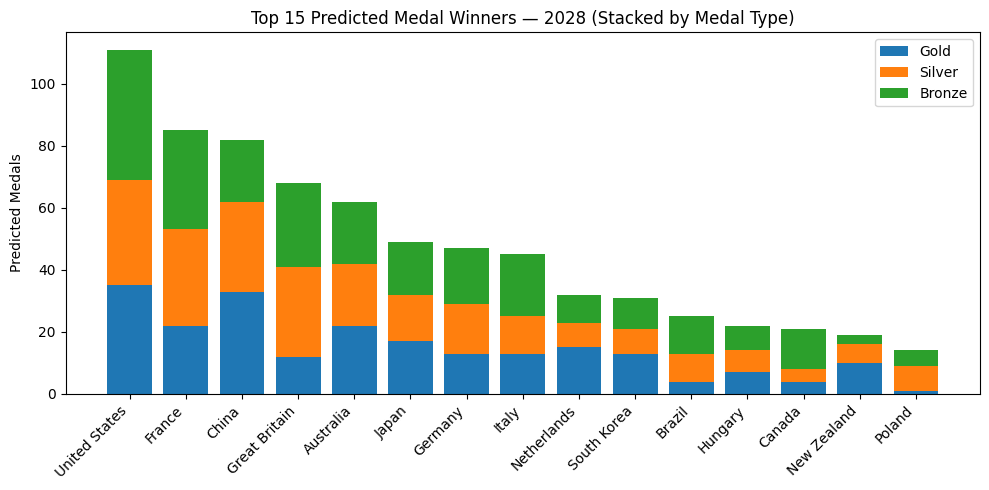

In [31]:
top = country_totals.head(15).copy()
x = np.arange(len(top))

plt.figure(figsize=(10,5))
plt.bar(x, top["Pred_Gold"], label="Gold")
plt.bar(x, top["Pred_Silver"], bottom=top["Pred_Gold"], label="Silver")
plt.bar(x, top["Pred_Bronze"], bottom=top["Pred_Gold"]+top["Pred_Silver"], label="Bronze")
plt.xticks(x, top["Country"], rotation=45, ha="right")
plt.title("Top 15 Predicted Medal Winners — 2028 (Stacked by Medal Type)")
plt.ylabel("Predicted Medals")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Insight:
# Total medals chart is simplest.
# Stacked medal chart shows whether a country wins mostly gold or mostly bronze/silver.

In [33]:
# 10) MEDAL EFFICIENCY (PER CAPITA)
# This is an excellent “insight” section: it highlights countries that overperform relative to size.

In [34]:
latest_pop = (
    df.sort_values("Year")
      .groupby("Country", as_index=False)["Population"]
      .last()
      .rename(columns={"Population":"Latest_Pop"})
)

eff = country_totals.merge(latest_pop, on="Country", how="left")
eff["Medals_per_Million"] = eff["Pred_Total"] / (eff["Latest_Pop"] / 1_000_000)

eff.sort_values("Medals_per_Million", ascending=False).head(20)

,Country,Pred_Gold,Pred_Silver,Pred_Bronze,Pred_Total,Latest_Pop,Medals_per_Million
75,Dominica,1.0,0.0,0.0,1.0,76369.0,13.094318
69,Saint Lucia,2.0,0.0,0.0,2.0,183774.0,10.882932
81,Grenada,1.0,0.0,0.0,1.0,110894.0,9.017620
13,New Zealand,10.0,6.0,3.0,19.0,4994118.0,3.804476
25,Croatia,3.0,0.0,7.0,10.0,4024852.0,2.484563
4,Australia,22.0,20.0,20.0,62.0,26573232.0,2.333175
11,Hungary,7.0,7.0,8.0,22.0,9477472.0,2.321294
16,Denmark,5.0,1.0,7.0,13.0,5889673.0,2.207253
70,Fiji,1.0,0.0,1.0,2.0,945843.0,2.114516
41,Jamaica,1.0,3.0,2.0,6.0,2931784.0,2.046535


In [35]:
# Insight:
# Efficiency analysis usually surfaces smaller, high-performing nations

In [36]:
pred_2028["Prev_Sport_Medals"] = pred_2028["Prev_Sport_Medals"].fillna(0)
pred_2028["Athlete_Count"] = pred_2028["Athlete_Count"].fillna(0).astype(int)

X_2028 = pred_2028[FEATURES]

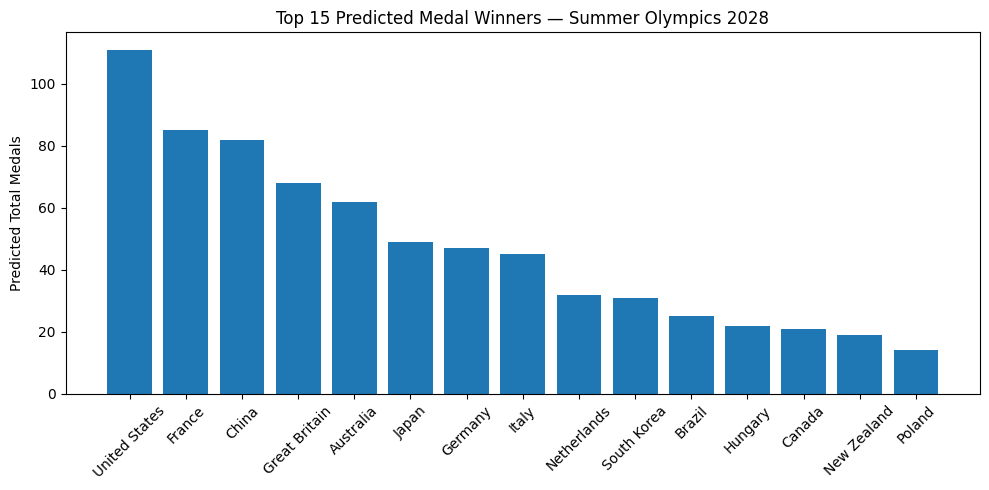

In [37]:
#Top 15 Countries Visualization
top15 = country_totals.head(15)
plt.figure(figsize=(10,5))
plt.bar(top15["Country"], top15["Pred_Total"])
plt.xticks(rotation=45)
plt.title("Top 15 Predicted Medal Winners — Summer Olympics 2028")
plt.ylabel("Predicted Total Medals")
plt.tight_layout()
plt.show()

In [38]:
# 11) FEATURE IMPORTANCE
# Feature importance helps explain why the model predicts what it predicts.
# Typically Prev_Sport_Medals is strongest because Olympic success is persistent.

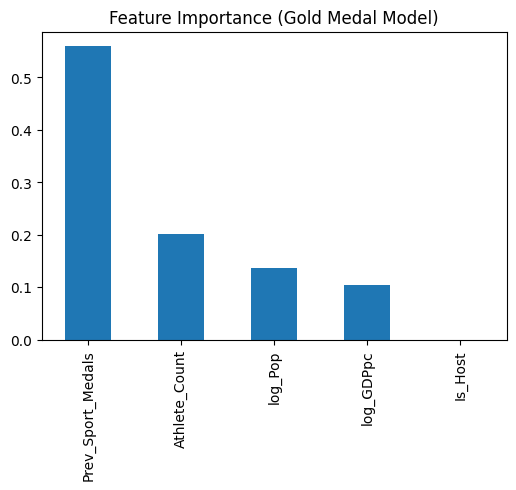

Prev_Sport_Medals    0.559351
Athlete_Count        0.200789
log_Pop              0.136409
log_GDPpc            0.103451
Is_Host              0.000000
dtype: float32

In [39]:
importance = pd.Series(
    models_all["Gold"].feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importance.plot(kind="bar")
plt.title("Feature Importance (Gold Medal Model)")
plt.show()

importance

In [40]:
# Insight:
# If Prev_Sport_Medals dominates too much, the model may be conservative (trend-following).
# Athlete_Count + GDPpc often add nuance and improve generalization.